# Actividad: Predicción del éxito académico

Dataset: **Students Dropout and Academic Success Dataset**

Objetivo: analizar los datos y comparar dos modelos sencillos de clasificación: **KNN** y **Naive Bayes**.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize


## 1. Cargar los datos

In [43]:
# El archivo usa ; como separador
df = pd.read_csv('data.csv', sep=';')

print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [44]:
# Información general
df.info()

print('\nValores faltantes:')
print(df.isnull().sum().sum())

print('\nDuplicados:', df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

## 2. Análisis exploratorio (EDA)

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


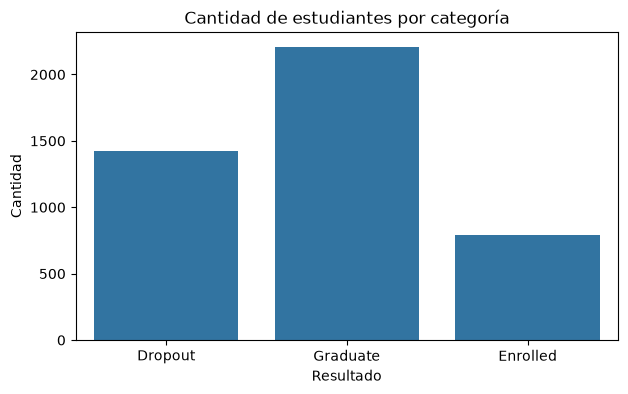

In [45]:
# Cantidad de estudiantes por clase
print(df['Target'].value_counts())

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Target')
plt.title('Cantidad de estudiantes por categoría')
plt.xlabel('Resultado')
plt.ylabel('Cantidad')
plt.show()

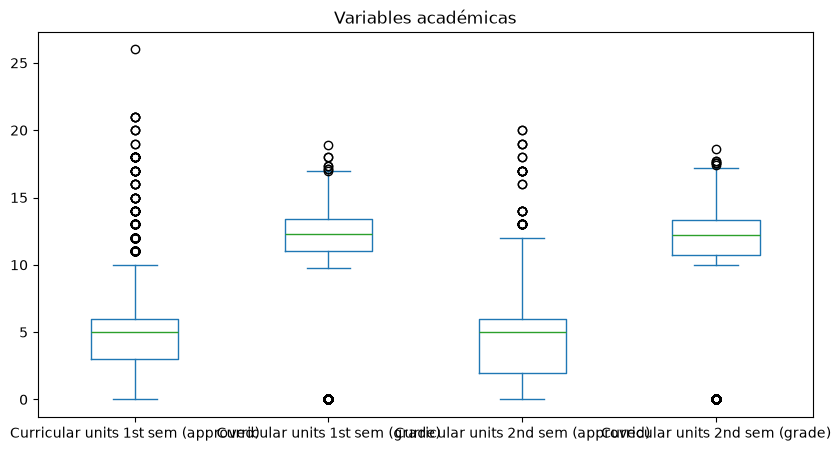

In [46]:
# Variables académicas
variables = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

df[variables].plot(kind='box', figsize=(10,5))
plt.title('Variables académicas')
plt.show()

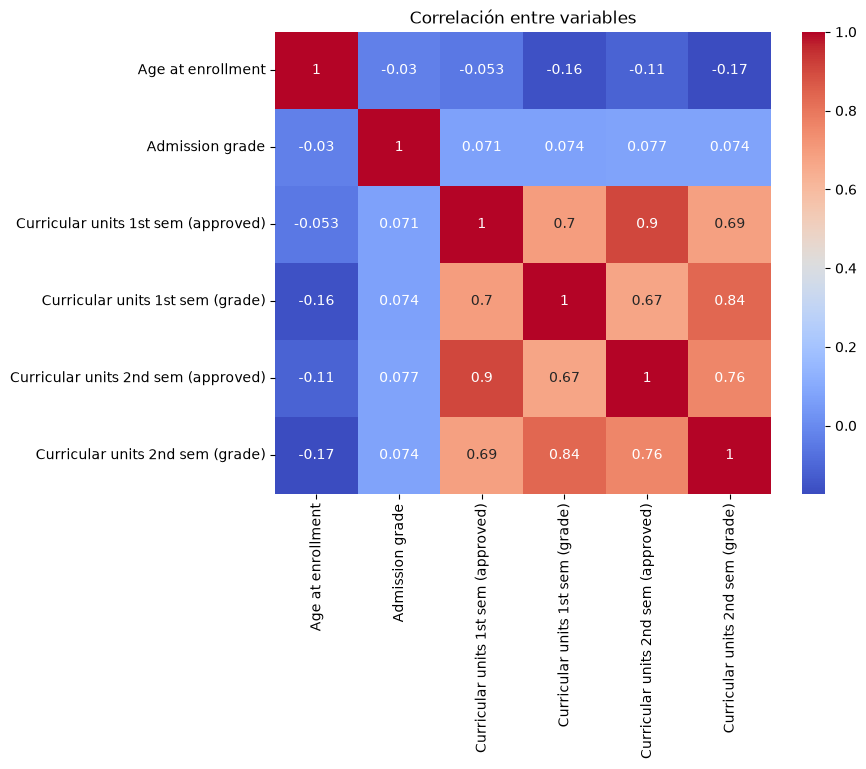

In [47]:
# Correlación de algunas variables
variables_corr = [
    'Age at enrollment',
    'Admission grade',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

plt.figure(figsize=(8,6))
sns.heatmap(df[variables_corr].corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables')
plt.show()

## 3. Preparar los datos para los modelos

In [48]:
X = df.drop('Target', axis=1)
y = df['Target']

# 80% para entrenar y 20% para probar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Datos de entrenamiento:', X_train.shape)
print('Datos de prueba:', X_test.shape)

Datos de entrenamiento: (3539, 36)
Datos de prueba: (885, 36)


## 4. Modelo KNN

In [57]:
# KNN necesita que las variables estén en una escala similar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)


In [58]:
print('Resultados KNN')
print('Accuracy:', round(accuracy_score(y_test, y_pred_knn), 3))
print('Balanced Accuracy:', round(balanced_accuracy_score(y_test, y_pred_knn), 3))
print('F1 Macro:', round(f1_score(y_test, y_pred_knn, average='macro'), 3))
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_knn))

Resultados KNN
Accuracy: 0.679
Balanced Accuracy: 0.581
F1 Macro: 0.586

Reporte de clasificación:
              precision    recall  f1-score   support

     Dropout       0.78      0.65      0.71       284
    Enrolled       0.32      0.23      0.27       159
    Graduate       0.71      0.86      0.78       442

    accuracy                           0.68       885
   macro avg       0.60      0.58      0.59       885
weighted avg       0.66      0.68      0.67       885



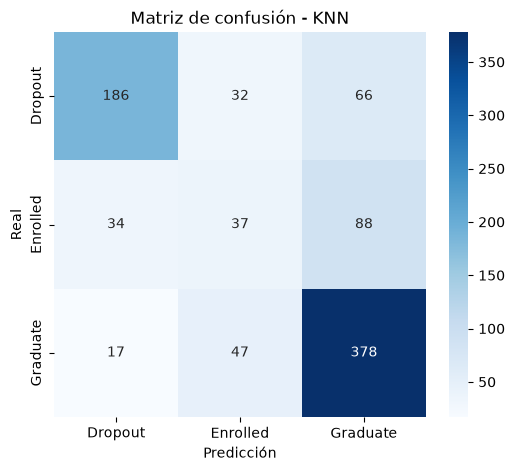

In [51]:
cm = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - KNN')
plt.show()

## 5. Modelo Naive Bayes

In [52]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)

print('Resultados Naive Bayes')
print('Accuracy:', round(accuracy_score(y_test, y_pred_nb), 3))
print('Balanced Accuracy:', round(balanced_accuracy_score(y_test, y_pred_nb), 3))
print('F1 Macro:', round(f1_score(y_test, y_pred_nb, average='macro'), 3))
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_nb))

Resultados Naive Bayes
Accuracy: 0.659
Balanced Accuracy: 0.558
F1 Macro: 0.558

Reporte de clasificación:
              precision    recall  f1-score   support

     Dropout       0.72      0.67      0.69       284
    Enrolled       0.27      0.18      0.22       159
    Graduate       0.70      0.83      0.76       442

    accuracy                           0.66       885
   macro avg       0.57      0.56      0.56       885
weighted avg       0.63      0.66      0.64       885



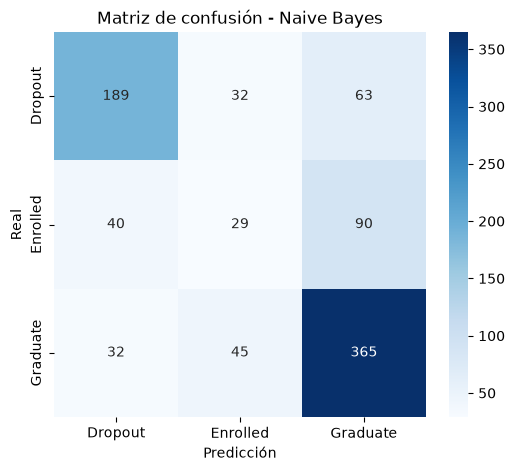

In [53]:
cm = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb.classes_, yticklabels=nb.classes_)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - Naive Bayes')
plt.show()

## 6. Comparación de modelos

In [54]:
resultados = pd.DataFrame({
    'Modelo': ['KNN', 'Naive Bayes'],
    'Accuracy': [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_nb)],
    'Balanced Accuracy': [balanced_accuracy_score(y_test, y_pred_knn), balanced_accuracy_score(y_test, y_pred_nb)],
    'F1 Macro': [f1_score(y_test, y_pred_knn, average='macro'), f1_score(y_test, y_pred_nb, average='macro')]
})

resultados.round(3)

,Modelo,Accuracy,Balanced Accuracy,F1 Macro
0,KNN,0.679,0.581,0.586
1,Naive Bayes,0.659,0.558,0.558


## 7. ROC-AUC

ROC-AUC KNN: 0.785
ROC-AUC Naive Bayes: 0.789


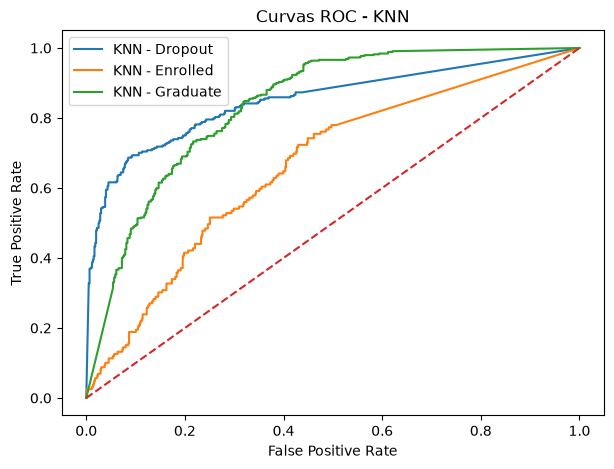

In [56]:
clases = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=clases)

auc_knn = roc_auc_score(y_test_bin, y_prob_knn, multi_class='ovr', average='macro')
auc_nb = roc_auc_score(y_test_bin, y_prob_nb, multi_class='ovr', average='macro')

print('ROC-AUC KNN:', round(auc_knn, 3))
print('ROC-AUC Naive Bayes:', round(auc_nb, 3))

plt.figure(figsize=(7,5))
for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    plt.plot(fpr, tpr, label='KNN - ' + clase)
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - KNN')
plt.legend()
plt.show()